# Thesis figures

Figures are grouped by thesis chapter so the figure source is easier to find. The shared imports and paths are defined once at the top.


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "Data").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find the Master_thesis repo root from the current working directory.")


REPO_ROOT = find_repo_root()
LATEX_DIR = REPO_ROOT.parent / "69c525a2d91967a989023aaf"
FIGURES_DIR = LATEX_DIR / "Figures"
IMAGES_DIR = LATEX_DIR / "Images"
LOCAL_FIGURES_DIR = REPO_ROOT / "figures"
DATA_DIR = REPO_ROOT / "Data"

for directory in (FIGURES_DIR, IMAGES_DIR, LOCAL_FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

print(f"Repo root: {REPO_ROOT}")
print(f"LaTeX figure directory: {FIGURES_DIR}")
print(f"LaTeX image directory: {IMAGES_DIR}")


Repo root: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
LaTeX figure directory: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Figures
LaTeX image directory: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Images


In [2]:
ISLAND_ID_TO_NAME = {
    "20": "Nes\u00f8y",
    "22": "Myken",
    "23": "Tr\u00e6na",
    "24": "Selv\u00e6r",
    "26": "Gjer\u00f8y",
    "27": "Hestmann\u00f8y",
    "28": "Indre Kvar\u00f8y",
    "33": "On\u00f8y og Lur\u00f8y",
    "34": "Lovund",
    "35": "Sleneset",
    "38": "Aldra",
    "60": "Leka",
    "61": "Vega",
    "63": "Vikna",
    "67": "Lauv\u00f8ya",
}


def style_axes(ax):
    ax.grid(True, alpha=0.25, linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def numeric_sort(values):
    return sorted(values, key=lambda value: int(value) if str(value).isdigit() else str(value))



## Methods

### AvgGRM-derived weighting schemes


(WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.pdf'),
 WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.png'))

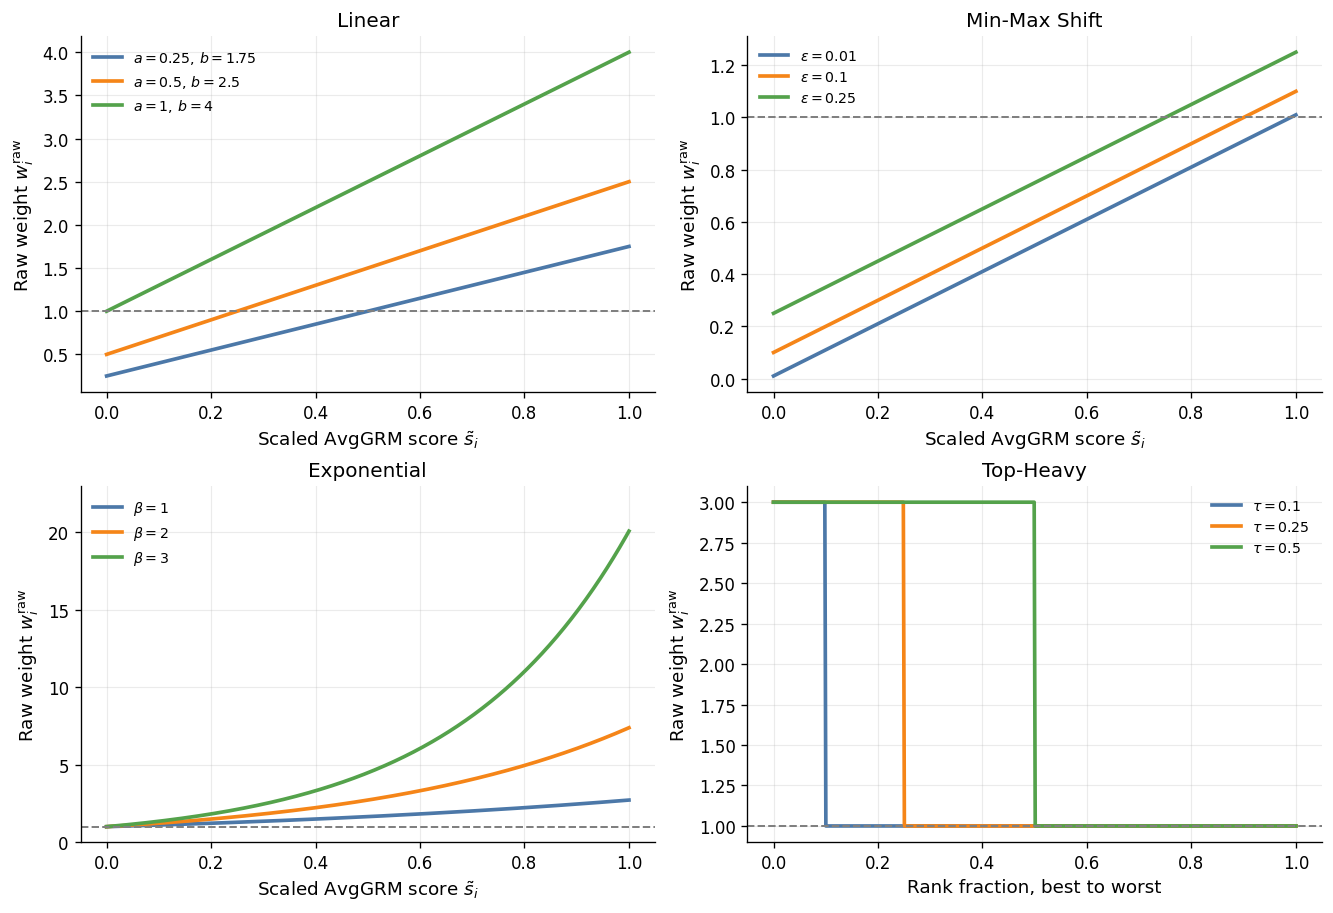

In [3]:
def plot_weighting_schemes(output_dir=FIGURES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    colors = ["#4C78A8", "#F58518", "#54A24B"]
    score = np.linspace(0.0, 1.0, 500)
    rank_frac = np.linspace(0.0, 1.0, 500)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

    ax = axes[0, 0]
    linear_params = [(0.25, 1.75), (0.50, 2.50), (1.00, 4.00)]
    for color, (a, b) in zip(colors, linear_params):
        ax.plot(score, a + (b - a) * score, color=color, lw=2.2, label=fr"$a={a:g},\, b={b:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Linear")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[0, 1]
    minmax_eps = [0.01, 0.10, 0.25]
    for color, eps in zip(colors, minmax_eps):
        ax.plot(score, eps + score, color=color, lw=2.2, label=fr"$\varepsilon={eps:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Min-Max Shift")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[1, 0]
    exp_betas = [1.0, 2.0, 3.0]
    for color, beta in zip(colors, exp_betas):
        ax.plot(score, np.exp(beta * score), color=color, lw=2.2, label=fr"$\beta={beta:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_ylim(0, 23)
    ax.set_title("Exponential")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[1, 1]
    top_fracs = [0.10, 0.25, 0.50]
    low = 1.0
    high = 3.0
    for color, tau in zip(colors, top_fracs):
        weights = np.where(rank_frac <= tau, high, low)
        ax.plot(rank_frac, weights, color=color, lw=2.2, label=fr"$\tau={tau:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Top-Heavy")
    ax.set_xlabel("Rank fraction, best to worst")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    for ax in axes.flat:
        ax.tick_params(labelsize=10)

    pdf_path = output_dir / "weighting_schemes.pdf"
    png_path = output_dir / "weighting_schemes.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, (pdf_path, png_path)


fig, weighting_paths = plot_weighting_schemes()
weighting_paths


## Results

### SNP PCA by island


(WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_1x3.pdf'),
 WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_1x3.png'))

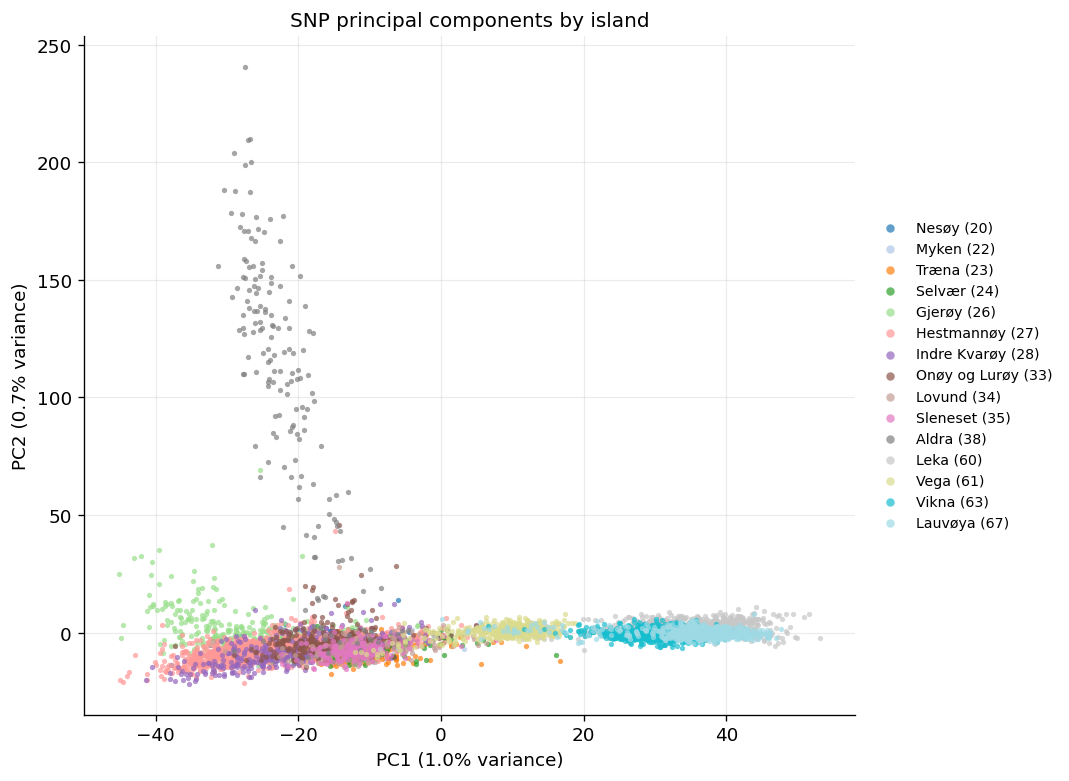

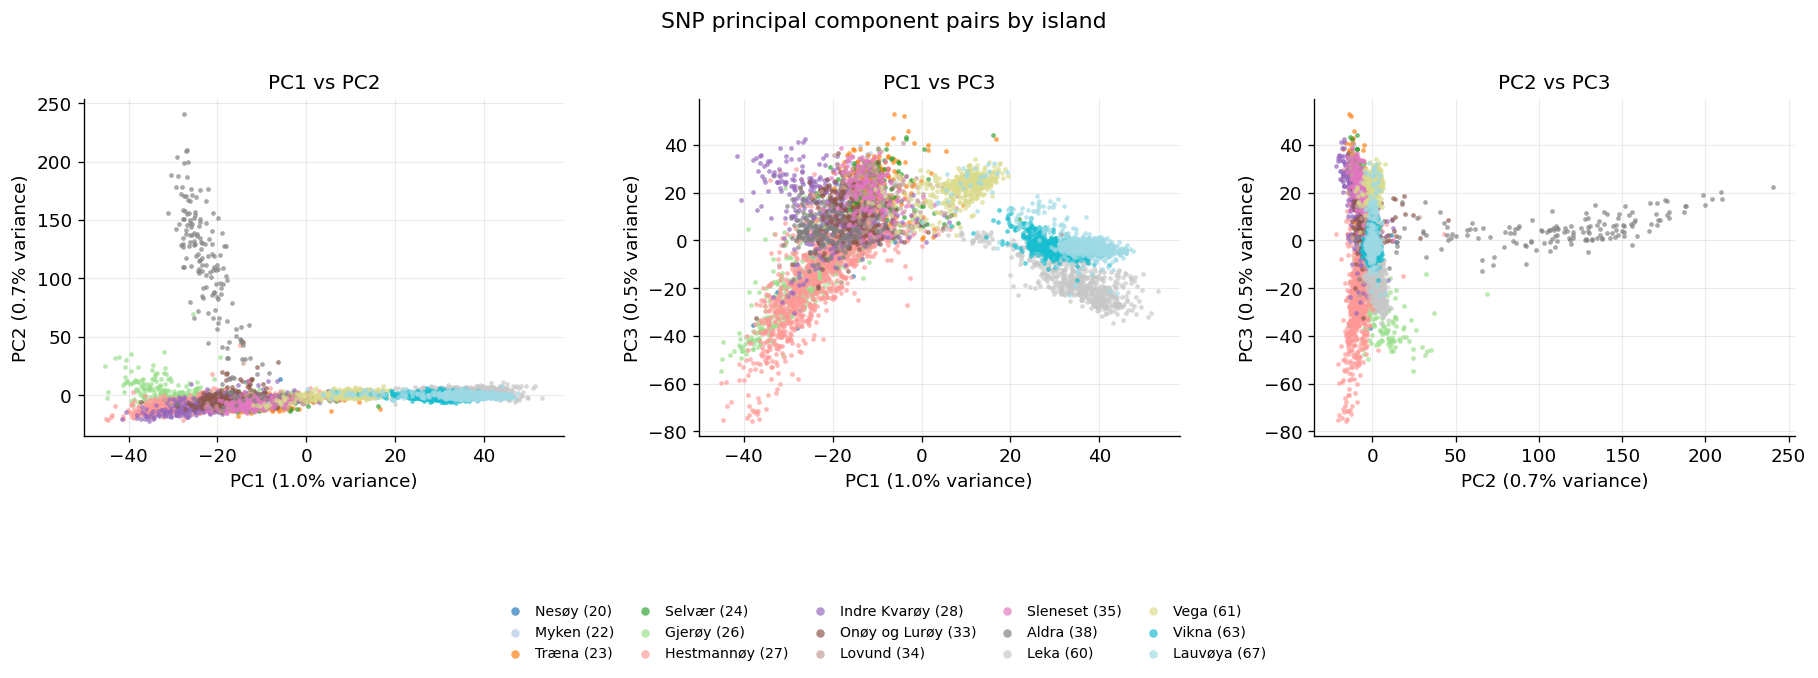

In [4]:
def load_snp_data_for_pca(npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz", min_count=20):
    data = np.load(npz_path, allow_pickle=False)
    X = data["snp"].astype(np.float32, copy=True)
    ids = data["ids"].astype(str)
    locality = data["locality"].astype(str)

    locality = np.where(locality == "68", "67", locality)
    counts = pd.Series(locality).value_counts()
    keep = counts[counts >= min_count].index.to_numpy()
    mask = np.isin(locality, keep)

    return X[mask], ids[mask], locality[mask]


def compute_snp_pca(X, n_components=2, standardize=True, max_snps=None, random_state=14):
    rng = np.random.default_rng(random_state)
    if max_snps is not None and max_snps < X.shape[1]:
        cols = np.sort(rng.choice(X.shape[1], size=int(max_snps), replace=False))
        X = X[:, cols]

    mean = X.mean(axis=0, dtype=np.float64).astype(np.float32)
    X = X - mean

    if standardize:
        std = X.std(axis=0, dtype=np.float64).astype(np.float32)
        std[std == 0] = 1.0
        X = X / std

    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=random_state)
    scores = pca.fit_transform(X)
    return scores, pca.explained_variance_ratio_


def plot_pca_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=2,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    cmap = plt.get_cmap("tab20", len(order))

    fig, ax = plt.subplots(figsize=(8.8, 6.4), constrained_layout=True)
    for idx, island_id in enumerate(order):
        sub = df[df["island_id"] == island_id]
        label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            s=10,
            alpha=0.70,
            linewidths=0,
            color=cmap(idx),
            label=label,
        )

    ax.set_xlabel(f"PC1 ({variance_ratio[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({variance_ratio[1] * 100:.1f}% variance)")
    ax.set_title("SNP principal components by island")
    style_axes(ax)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        markerscale=1.6,
        borderaxespad=0.0,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pc1_pc2.pdf"
    png_path = output_dir / "pca_island_pc1_pc2.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_scores, pca_variance_ratio, pca_paths = plot_pca_by_island()
pca_paths


def plot_pca_pairwise_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=3,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "PC3": scores[:, 2],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    cmap = plt.get_cmap("tab20", len(order))
    pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2), constrained_layout=False)
    handles = []
    labels = []

    for ax, (x_col, y_col) in zip(axes, pairs):
        for idx, island_id in enumerate(order):
            sub = df[df["island_id"] == island_id]
            label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
            scatter = ax.scatter(
                sub[x_col],
                sub[y_col],
                s=8,
                alpha=0.68,
                linewidths=0,
                color=cmap(idx),
                label=label,
            )
            if ax is axes[0]:
                handles.append(scatter)
                labels.append(label)

        x_idx = int(x_col[-1]) - 1
        y_idx = int(y_col[-1]) - 1
        ax.set_xlabel(f"{x_col} ({variance_ratio[x_idx] * 100:.1f}% variance)")
        ax.set_ylabel(f"{y_col} ({variance_ratio[y_idx] * 100:.1f}% variance)")
        ax.set_title(f"{x_col} vs {y_col}")
        style_axes(ax)

    fig.suptitle("SNP principal component pairs by island", y=0.98)
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
        ncol=5,
        markerscale=1.8,
        columnspacing=1.2,
        handletextpad=0.4,
    )
    fig.subplots_adjust(left=0.07, right=0.99, top=0.84, bottom=0.30, wspace=0.28)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pairwise_1x3.pdf"
    png_path = output_dir / "pca_island_pairwise_1x3.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_pairwise_scores, pca_pairwise_variance_ratio, pca_pairwise_paths = plot_pca_pairwise_by_island()
pca_pairwise_paths



### Across-population ridge baselines

The 20k SNP ridge baseline is averaged across SNP-repeat seeds within each target island before plotting. The all-SNP and PC-based ridge baselines have one value per target island.

In [5]:
import json

FINAL_RESULTS_DIR = REPO_ROOT / "outputs" / "final_results"
RIDGE_ACROSS_POP_DIR = FINAL_RESULTS_DIR / "ridge_across_pop_alpha1e5"
RIDGE_ACROSS_POP_STEM = "ridge_across_pop_alpha1e5"

TRAIT_LABELS = {
    "body_mass": "Body mass",
    "thr_tarsus": "Tarsus length",
    "thr_wing": "Wing length",
}

RIDGE_METHOD_LABELS = {
    "all_snps": "Ridge, all SNPs",
    "random_20k_snps": "Ridge, 20k random SNPs",
    "pcs_1000": "Ridge, 1000 PCs",
}
RIDGE_METHOD_ORDER = [
    "Ridge, all SNPs",
    "Ridge, 20k random SNPs",
    "Ridge, 1000 PCs",
]


def load_ridge_across_pop_results(
    results_dir=RIDGE_ACROSS_POP_DIR,
    file_stem=RIDGE_ACROSS_POP_STEM,
):
    results_dir = Path(results_dir)
    csv_path = results_dir / f"{file_stem}_per_fold_results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
        return df

    rows = []
    for json_path in sorted(results_dir.rglob(f"{file_stem}_results.json")):
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                payload = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping partially written JSON: {json_path.relative_to(REPO_ROOT)}")
            continue

        rel_parts = json_path.relative_to(results_dir).parts
        config_used = payload.get("config_used", {})
        trait = rel_parts[0] if rel_parts else config_used.get("trait")
        snp_experiment = config_used.get("snp_experiment")
        if snp_experiment is None and len(rel_parts) >= 3:
            snp_experiment = rel_parts[2]

        snp_repeat = config_used.get("snp_repeat")
        repeat_name = json_path.parent.name
        if snp_repeat is None and repeat_name.startswith("repeat_"):
            snp_repeat = int(repeat_name.split("_", 1)[1])

        for fold in payload.get("per_fold", []):
            rows.append(
                {
                    "trait": trait,
                    "snp_experiment": snp_experiment,
                    "snp_repeat": snp_repeat,
                    "snp_seed": config_used.get("snp_seed"),
                    "num_snps_requested": config_used.get("num_snps_requested"),
                    "n_pcs_requested": config_used.get("n_pcs_requested"),
                    "use_pcs": config_used.get("use_pcs"),
                    "n_features_fit": config_used.get("n_features_fit"),
                    "alpha": config_used.get("alpha"),
                    "source_file": str(json_path.relative_to(REPO_ROOT)),
                    **fold,
                }
            )

    return pd.DataFrame(rows)


def prepare_ridge_across_pop_boxplot_df(raw_df):
    columns = [
        "trait",
        "trait_label",
        "snp_experiment",
        "method",
        "target_island_key",
        "target_island",
        "test_island_code",
        "pearson_r",
        "n_repeats_available",
    ]
    if raw_df.empty:
        return pd.DataFrame(columns=columns)

    df = raw_df[raw_df["snp_experiment"].isin(RIDGE_METHOD_LABELS)].copy()
    if df.empty:
        return pd.DataFrame(columns=columns)

    if "test_island_original_label" not in df.columns:
        df["test_island_original_label"] = pd.NA

    original_label = df["test_island_original_label"].astype("string")
    code_label = df["test_island_code"].astype("string")
    df["target_island_key"] = original_label.fillna(code_label)
    df["target_island"] = df["test_island"].fillna(df["target_island_key"])

    grouped = (
        df.groupby(
            [
                "trait",
                "snp_experiment",
                "target_island_key",
                "target_island",
                "test_island_code",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            pearson_r=("pearson_r", "mean"),
            n_repeats_available=("snp_repeat", "nunique"),
            n_fold_rows=("pearson_r", "size"),
        )
    )
    grouped["method"] = grouped["snp_experiment"].map(RIDGE_METHOD_LABELS)
    grouped["trait_label"] = grouped["trait"].map(TRAIT_LABELS).fillna(grouped["trait"])
    return grouped[columns].sort_values(["trait", "method", "test_island_code"])


ridge_across_pop_raw = load_ridge_across_pop_results()
ridge_across_pop_box_df = prepare_ridge_across_pop_boxplot_df(ridge_across_pop_raw)

print(f"Loaded {len(ridge_across_pop_raw)} ridge per-fold rows")
ridge_across_pop_box_df.groupby(["trait", "method"], dropna=False).size()

Loaded 270 ridge per-fold rows


trait       method                
body_mass   Ridge, 20k random SNPs    15
            Ridge, all SNPs           15
thr_tarsus  Ridge, 20k random SNPs    15
            Ridge, all SNPs           15
thr_wing    Ridge, 20k random SNPs    15
            Ridge, all SNPs           15
dtype: int64

{'body_mass': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_body_mass.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_body_mass.png')),
 'thr_tarsus': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_tarsus.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_tarsus.png')),
 'thr_wing': (WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_wing.pdf'),
  WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/across_pop_prediction_boxplot_thr_wing.png'))}

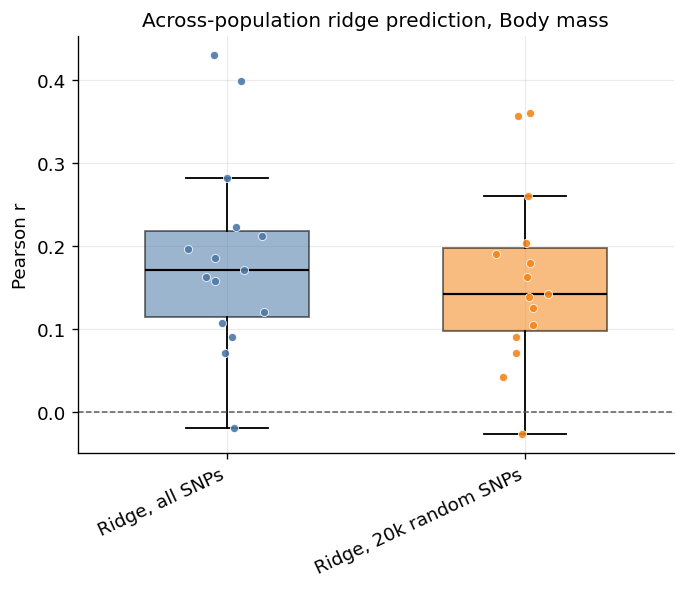

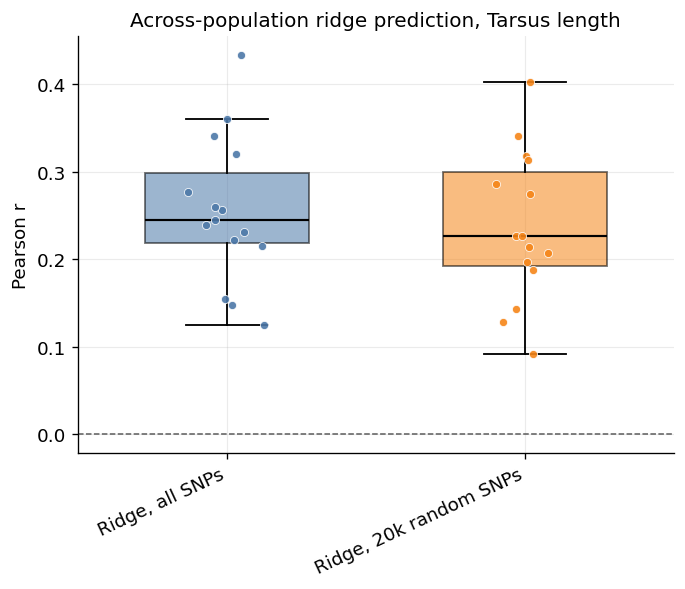

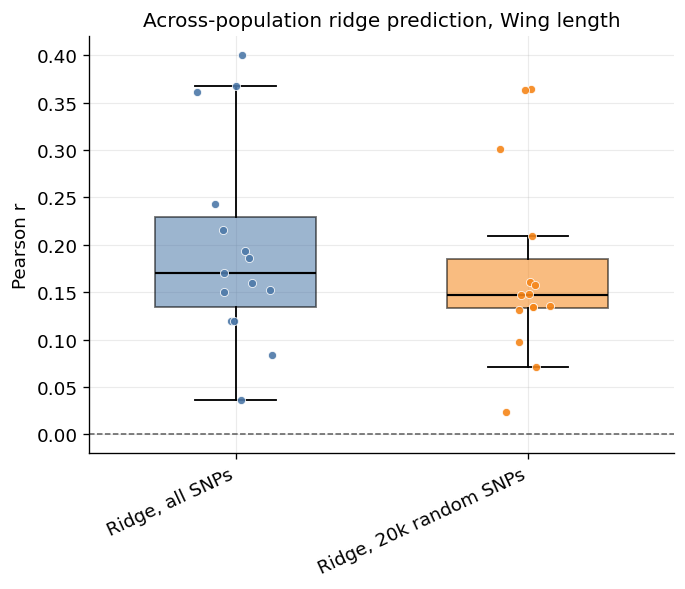

In [6]:
def plot_across_pop_prediction_boxplots_by_trait(
    box_df,
    output_dir=FIGURES_DIR,
    file_stem="across_pop_prediction_boxplot",
    method_order=None,
    trait_order=None,
):
    if box_df.empty:
        print("No across-population ridge results found yet.")
        return {}

    method_order = list(method_order or RIDGE_METHOD_ORDER)
    method_order = [m for m in method_order if m in set(box_df["method"])]
    method_order += [m for m in box_df["method"].dropna().unique() if m not in method_order]

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(box_df["trait"])])
    trait_order += [t for t in box_df["trait"].dropna().unique() if t not in trait_order]

    colors = {
        "Ridge, all SNPs": "#4C78A8",
        "Ridge, 20k random SNPs": "#F58518",
        "Ridge, 1000 PCs": "#54A24B",
    }
    fallback_colors = plt.get_cmap("tab10")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths_by_trait = {}

    for trait in trait_order:
        sub = box_df[box_df["trait"] == trait]
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
        rng = np.random.default_rng(14)
        for pos, method in enumerate(method_order):
            values = sub.loc[sub["method"] == method, "pearson_r"].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue

            color = colors.get(method, fallback_colors(pos % 10))
            box = ax.boxplot(
                [values],
                positions=[pos],
                widths=0.55,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "black", "linewidth": 1.3},
                boxprops={"linewidth": 1.1},
                whiskerprops={"linewidth": 1.1},
                capprops={"linewidth": 1.1},
            )
            box["boxes"][0].set_facecolor(color)
            box["boxes"][0].set_alpha(0.55)

            jitter = rng.normal(0.0, 0.045, size=len(values))
            ax.scatter(
                np.full(len(values), pos) + jitter,
                values,
                s=24,
                color=color,
                edgecolor="white",
                linewidth=0.5,
                alpha=0.9,
                zorder=3,
            )

        ax.axhline(0, color="0.35", linewidth=0.9, linestyle="--")
        ax.set_title(f"Across-population ridge prediction, {TRAIT_LABELS.get(trait, trait)}")
        ax.set_ylabel("Pearson r")
        ax.set_xticks(range(len(method_order)))
        ax.set_xticklabels(method_order, rotation=25, ha="right")
        style_axes(ax)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        fig.savefig(pdf_path, bbox_inches="tight")
        fig.savefig(png_path, bbox_inches="tight")
        paths_by_trait[trait] = (pdf_path, png_path)

    return paths_by_trait


ridge_across_pop_paths = plot_across_pop_prediction_boxplots_by_trait(ridge_across_pop_box_df)
ridge_across_pop_paths

### E1: PC-ridge nested LOIO

Nested leave-one-island-out tuning of (r, lambda) per outer target island. PCs are fit on the outer-/inner-train subset only. Results are loaded per trait from `outputs/final_results/e1_pc_ridge_nested_loio/<trait>/`.


In [ ]:
E1_DIR = FINAL_RESULTS_DIR / "e1_pc_ridge_nested_loio"
E1_STEM = "e1_pc_ridge_nested_loio"


def load_e1_pc_ridge_results(results_dir=E1_DIR, file_stem=E1_STEM):
    """Load per-fold results and best-params across all traits.

    Returns
    -------
    per_fold_df : DataFrame with one row per (trait, outer fold)
    best_params : dict trait -> list of per-fold best params (from JSON)
    """
    results_dir = Path(results_dir)
    fold_frames = []
    best_params = {}

    if not results_dir.exists():
        return pd.DataFrame(), best_params

    for trait_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        trait = trait_dir.name
        csv_path = trait_dir / f"{file_stem}_per_fold_results.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            if "trait" not in df.columns:
                df["trait"] = trait
            df["source_file"] = str(csv_path.relative_to(REPO_ROOT))
            fold_frames.append(df)

        bp_path = trait_dir / f"{file_stem}_best_params.json"
        if bp_path.exists():
            with open(bp_path, "r", encoding="utf-8") as f:
                best_params[trait] = json.load(f)

    per_fold_df = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    return per_fold_df, best_params


def summarize_e1_best_params(per_fold_df):
    """Mode r and geometric-mean alpha across outer folds, per trait."""
    if per_fold_df.empty:
        return pd.DataFrame(columns=["trait", "best_n_pcs_mode", "best_alpha_geomean", "pearson_r_mean", "pearson_r_std", "n_folds"])
    rows = []
    for trait, sub in per_fold_df.groupby("trait", sort=False):
        rows.append({
            "trait": trait,
            "trait_label": TRAIT_LABELS.get(trait, trait),
            "best_n_pcs_mode": int(sub["best_n_pcs"].mode().iloc[0]),
            "best_n_pcs_median": float(sub["best_n_pcs"].median()),
            "best_alpha_geomean": float(np.exp(np.log(sub["best_alpha"]).mean())),
            "best_alpha_median": float(sub["best_alpha"].median()),
            "pearson_r_mean": float(sub["pearson_r"].mean()),
            "pearson_r_std": float(sub["pearson_r"].std()),
            "n_folds": int(sub.shape[0]),
        })
    return pd.DataFrame(rows)


e1_per_fold_df, e1_best_params = load_e1_pc_ridge_results()
e1_summary_df = summarize_e1_best_params(e1_per_fold_df)
print(f"Loaded {len(e1_per_fold_df)} E1 per-fold rows across {e1_per_fold_df['trait'].nunique() if not e1_per_fold_df.empty else 0} traits")
e1_summary_df


In [ ]:
def plot_e1_pc_ridge_loio_by_trait(
    per_fold_df,
    output_dir=FIGURES_DIR,
    file_stem="e1_pc_ridge_nested_loio",
    trait_order=None,
):
    """One panel per trait: per-island Pearson r as a strip, with best (r, lambda) annotated."""
    if per_fold_df.empty:
        print("No E1 results yet.")
        return {}

    trait_order = list(trait_order or [t for t in TRAIT_LABELS if t in set(per_fold_df["trait"])])
    trait_order += [t for t in per_fold_df["trait"].dropna().unique() if t not in trait_order]

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    for trait in trait_order:
        sub = per_fold_df[per_fold_df["trait"] == trait].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("test_island")

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True,
                                 gridspec_kw={"width_ratios": [1.0, 1.0]})

        ax = axes[0]
        x = np.arange(len(sub))
        ax.bar(x, sub["pearson_r"].to_numpy(), color="#4C78A8", alpha=0.75, edgecolor="white")
        ax.axhline(float(sub["pearson_r"].mean()), color="0.25", lw=1.2, ls="--",
                   label=f"mean r = {sub['pearson_r'].mean():.3f}")
        ax.axhline(0, color="0.5", lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["test_island"].astype(str), rotation=35, ha="right")
        ax.set_ylabel("Pearson r")
        ax.set_title(f"PC-ridge nested LOIO, {TRAIT_LABELS.get(trait, trait)}")
        ax.legend(frameon=False, loc="best")
        style_axes(ax)

        ax = axes[1]
        ax.scatter(sub["best_n_pcs"], sub["best_alpha"], s=42, color="#F58518",
                   edgecolor="white", linewidth=0.6, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(str(row["test_island"]),
                        (row["best_n_pcs"], row["best_alpha"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=7)
        ax.set_yscale("log")
        ax.set_xlabel("Selected r (number of PCs)")
        ax.set_ylabel(r"Selected $\lambda$ (log)")
        ax.set_title("Per-fold selected hyperparameters")
        style_axes(ax)

        pdf_path = output_dir / f"{file_stem}_{trait}.pdf"
        png_path = output_dir / f"{file_stem}_{trait}.png"
        fig.savefig(pdf_path, bbox_inches="tight")
        fig.savefig(png_path, bbox_inches="tight")
        paths[trait] = (pdf_path, png_path)

    return paths


e1_figure_paths = plot_e1_pc_ridge_loio_by_trait(e1_per_fold_df)
e1_figure_paths
